# Project 2 — Lid-Driven Cavity Flow

Incompressible Navier-Stokes solver using:
- **Fractional Step (Projection) Method** (3 sub-steps)
- **Staggered MAC grid** (pressure at cell centers, velocities at faces)
- **Crank-Nicolson** for viscous terms
- **2nd-order Adams-Bashforth** for advection
- **Conjugate Gradient** linear solver (via `scipy`)

## Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.sparse.linalg import cg, LinearOperator

## Parameters

In [12]:
nx = 64
ny = 64
Lx = 1.0
Ly = 1.0
Ustar = 1.0
Re = 100.0
visc = Ustar * Lx / Re
CFL = 0.2

# Domain extent
xL = 0.0
xR = xL + Lx
yB = 0.0
yT = yB + Ly

# Discretization
# NOTE: renamed from 'np' to 'n_cells' to avoid shadowing numpy
n_cells = nx * ny                        # number of pressure DOFs
n_vel   = ny * (nx - 1) + nx * (ny - 1) # number of velocity DOFs
dx = Lx / nx
dy = Ly / ny
dt = CFL * dx
max_step = 500
end_time = max_step * dt

print(f"dt = {dt:.5f}, n_cells = {n_cells}, n_vel = {n_vel}")

dt = 0.00313, n_cells = 4096, n_vel = 8064


## Grid Indexing

Build pointer arrays that map 2D grid indices `(i, j)` to flat 1D array indices.

- `ip[i, j]` — index of pressure at cell center `(i, j)`, `i=0..nx-1`, `j=0..ny-1`
- `iu[i, j]` — index of u-velocity at vertical face between columns `i-1` and `i`, `i=1..nx-1`
- `iv[i, j]` — index of v-velocity at horizontal face between rows `j-1` and `j`, `j=1..ny-1`

Invalid entries (boundaries with no DOF) are set to `-1`.

In [13]:
def func_gen_pointer(nx, ny):
    """
    Generate flat-array index pointers for staggered grid variables.
    Uses 0-based indexing. Invalid (boundary) entries are -1.
    """
    # Pressure: all (nx, ny) cells are DOFs
    ip = np.full((nx, ny), -1, dtype=int)
    count = 0
    for i in range(nx):
        for j in range(ny):
            ip[i, j] = count
            count += 1

    # u-velocity: interior vertical faces, i = 1..nx-1
    iu = np.full((nx + 1, ny), -1, dtype=int)
    count = 0
    for i in range(1, nx):   # i=1..nx-1
        for j in range(ny):
            iu[i, j] = count
            count += 1

    # v-velocity: interior horizontal faces, j = 1..ny-1
    # NOTE: v-DOFs follow u-DOFs in the flat velocity vector, so offset by ny*(nx-1)
    iv = np.full((nx, ny + 1), -1, dtype=int)
    count = ny * (nx - 1)
    for i in range(nx):
        for j in range(1, ny):   # j=1..ny-1
            iv[i, j] = count
            count += 1

    return ip, iu, iv


ip, iu, iv = func_gen_pointer(nx, ny)
print(f"ip range: [{ip.min()}, {ip.max()}]")
print(f"iu DOFs: {(iu >= 0).sum()}  (expected {ny*(nx-1)})")
print(f"iv DOFs: {(iv >= 0).sum()}  (expected {nx*(ny-1)})")

ip range: [0, 4095]
iu DOFs: 4032  (expected 4032)
iv DOFs: 4032  (expected 4032)


## Grid Generation

Physical coordinates of each variable location on the staggered grid.

In [14]:
def func_gen_grid(nx, ny, xL, xR, yB, yT, dx, dy):
    """
    Generate coordinate arrays for each variable type on the staggered grid.

    Returns
    -------
    xp, yp : 1D arrays, pressure cell-center coordinates
    xu, yu : 1D arrays, u-velocity face coordinates (vertical faces, i=1..nx-1)
    xv, yv : 1D arrays, v-velocity face coordinates (horizontal faces, j=1..ny-1)
    """
    # Pressure cell centers
    xp = np.linspace(xL + dx / 2, xR - dx / 2, nx)
    yp = np.linspace(yB + dy / 2, yT - dy / 2, ny)

    # u-velocity: on vertical (x-direction) interior faces
    xu = np.linspace(xL + dx, xR - dx, nx - 1)  # x-coords of interior vertical faces
    yu = yp.copy()                                # same y as pressure centers

    # v-velocity: on horizontal (y-direction) interior faces
    xv = xp.copy()                                # same x as pressure centers
    yv = np.linspace(yB + dy, yT - dy, ny - 1)  # y-coords of interior horizontal faces

    return xp, yp, xu, yu, xv, yv


xp, yp, xu, yu, xv, yv = func_gen_grid(nx, ny, xL, xR, yB, yT, dx, dy)

## Boundary Conditions

Lid-driven cavity: top wall moves at `Ustar`, all others are no-slip.

In [15]:
# u-velocity BCs — uBC_B/uBC_T shape (nx-1,): one value per interior u-face
uBC_T = Ustar * np.ones(nx - 1)   # top wall moves at Ustar
uBC_B = np.zeros(nx - 1)          # bottom wall: no-slip
uBC_L = np.zeros(ny)              # left wall: no-slip
uBC_R = np.zeros(ny)              # right wall: no-slip

# v-velocity BCs — vBC_L/vBC_R shape (ny-1,): one value per interior v-face
vBC_T = np.zeros(nx)
vBC_B = np.zeros(nx)
vBC_L = np.zeros(ny - 1)
vBC_R = np.zeros(ny - 1)

## Initialization

Start from rest, or load a previous solution from `Results.npz`.

In [16]:
Init_Soln = True   # set False to attempt loading from Results.npz

if Init_Soln or not os.path.exists('Results.npz'):
    P    = np.zeros(n_cells)
    U    = np.zeros(n_vel)
    time = 0.0
    step = 0
else:
    data = np.load('Results.npz')
    P    = data['P']
    U    = data['U']
    time = float(data['time'])
    step = int(data['step'])
    print(f"Loaded solution at t={time:.4f}, step={step}")

## Discrete Operators

### Divergence `D`
Maps velocity vector (length `n_vel`) → pressure space (length `n_cells`).

### Gradient `G`
Maps pressure vector (length `n_cells`) → velocity space (length `n_vel`). **TODO**

### Laplacian `L`
Applies discrete Laplacian to the velocity vector. **TODO**

### Composite operators
| Symbol | Expression | Role |
|--------|-----------|------|
| `S`    | `I + dt/2·ν·L` | Explicit viscous half-step |
| `R`    | `I - dt/2·ν·L` | Implicit viscous half-step (LHS of Step 1) |
| `T`    | `D·S·G`        | Pressure Poisson operator (LHS of Step 2) |
| `C`    | `S·G`          | Velocity correction (Step 3) |

In [17]:
import operators as ops

def laplace_x(x):
    return ops.L(x, dx, iu, iv, nx, ny, n_vel)


def bc_laplace():
    return ops.bc_L(uBC_L, uBC_R, uBC_B, uBC_T,
                    vBC_L, vBC_R, vBC_B, vBC_T,
                    dx, iu, iv, nx, ny, n_vel)


def bc_div():
    return ops.bc_D(uBC_L, uBC_R, vBC_B, vBC_T,
                    dx, ip, nx, ny, n_cells)


def opt_D(x):
    return ops.D(x, dx, ip, iu, iv, nx, ny, n_cells)


def opt_G(x):
    return ops.G(x, dx, ip, iu, iv, nx, ny, n_vel)


def adv(vel):
    return ops.A(vel,
                 uBC_L, uBC_R, uBC_B, uBC_T,
                 vBC_L, vBC_R, vBC_B, vBC_T,
                 dx, iu, iv, nx, ny, n_vel)


def cg_solve(op, b, tol=1e-8):
    A_op = LinearOperator((len(b), len(b)), matvec=op)
    x, info = cg(A_op, b, tol=tol)
    if info != 0:
        print(f"  CG warning: info={info}")
    return x


def pin_pressure(x):
    """Zero out the ip[0,0] DOF to fix the pressure constant (T = D·S·G is singular)."""
    y = x.copy()
    y[ip[0, 0]] = 0.0
    return y


def opt_S(x):
    return x + (dt / 2.0 * visc) * laplace_x(x)


def opt_R(x):
    return x - (dt / 2.0 * visc) * laplace_x(x)


def opt_T(x):
    return pin_pressure(opt_D(opt_S(opt_G(x))))


def opt_C(x):
    return opt_S(opt_G(x))

## Time Loop — Fractional Step Method

**Step 1** — Solve for intermediate velocity `U*`:
$$
\underbrace{(I - \tfrac{\Delta t}{2}\nu L)}_{R} U^* =
\underbrace{(I + \tfrac{\Delta t}{2}\nu L)}_{S} U^n
+ \Delta t \left(\tfrac{3}{2} N^n - \tfrac{1}{2} N^{n-1}\right)
+ \Delta t\, \nu\, \text{BC}_L
$$

**Step 2** — Solve pressure Poisson equation:
$$
\underbrace{D\,S\,G}_{T}\, P = \frac{1}{\Delta t}\left(D\,U^* + \text{BC}_D\right)
$$

**Step 3** — Correct velocity to enforce $\nabla\cdot U = 0$:
$$
U^{n+1} = U^* - \Delta t\, C\, P
$$

In [18]:
adv_prev = np.zeros(n_vel)   # N(U) at step n-1 for Adams-Bashforth startup

while time < end_time:
    step += 1
    time += dt

    adv0 = adv(U)
    adv1 = adv_prev

    # --- Step 1: intermediate velocity ---
    RHS_U = opt_S(U) + dt * (1.5 * adv0 - 0.5 * adv1) + dt * visc * bc_laplace()
    UF = cg_solve(opt_R, RHS_U, tol=1e-8)

    # --- Step 2: pressure Poisson ---
    # T = D·S·G is singular (null space = constant P); pin ip[0,0] to fix the constant.
    RHS_P = opt_D(UF) / dt + bc_div() / dt
    RHS_P[ip[0, 0]] = 0.0
    P = cg_solve(opt_T, RHS_P, tol=1e-8)

    # --- Step 3: velocity correction ---
    U = UF - dt * opt_C(P)

    adv_prev = adv0

    if step % 100 == 0:
        res = np.linalg.norm(U - UF) / (np.linalg.norm(U) + 1e-15)
        print(f"step={step:5d}  t={time:.4f}  ||U||={np.linalg.norm(U):.4e}  res={res:.2e}")

# Save results
np.savez('Results.npz', P=P, U=U, time=time, step=step)

step=  100  t=0.3125  ||U||=1.1062e+01  res=2.74e-02
step=  200  t=0.6250  ||U||=1.2669e+01  res=2.42e-02
step=  300  t=0.9375  ||U||=1.3583e+01  res=2.27e-02
step=  400  t=1.2500  ||U||=1.4198e+01  res=2.19e-02
step=  500  t=1.5625  ||U||=1.4646e+01  res=2.13e-02


## Post-Processing / Visualization

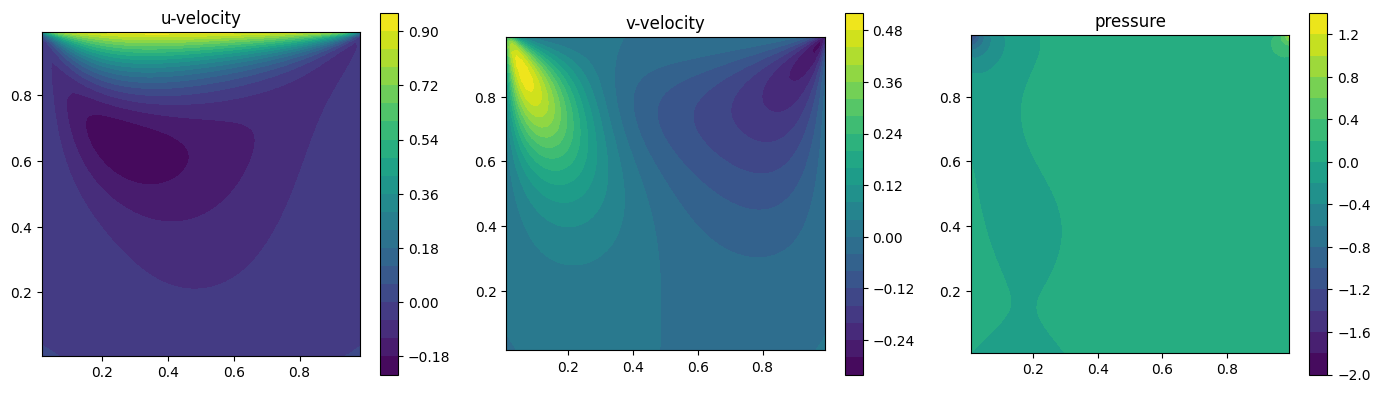

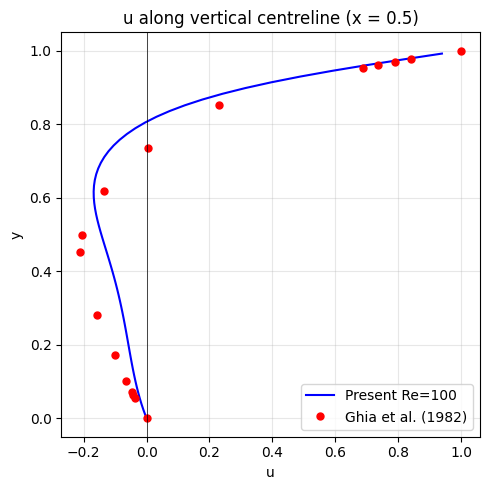

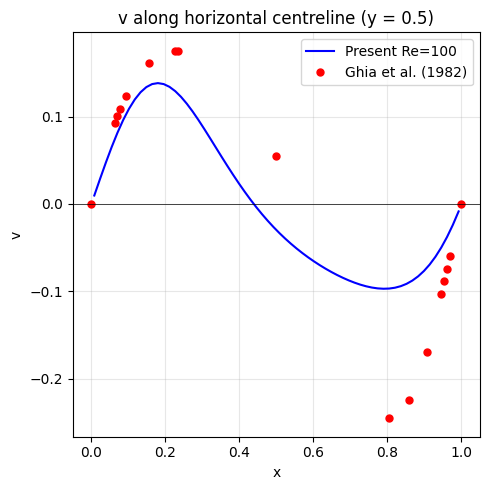

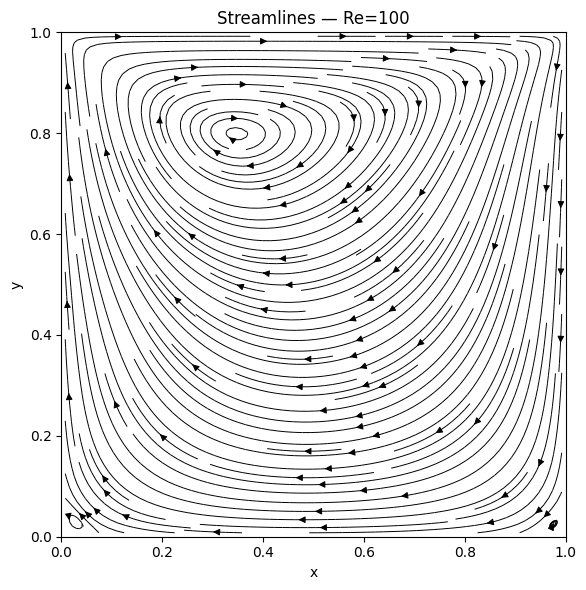

In [19]:
# Ghia et al. (1982) Table 1 — Re = 100
# u along vertical centreline (x = 0.5)
ghia_u_y = np.array([0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719, 0.2813,
                      0.4531, 0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609,
                      0.9688, 0.9766, 1.0000])
ghia_u   = np.array([0.00000, -0.03717, -0.04192, -0.04775, -0.06434, -0.10150,
                     -0.15662, -0.21090, -0.20581, -0.13641,  0.00332,  0.23151,
                      0.68717,  0.73722,  0.78871,  0.84123,  1.00000])

# v along horizontal centreline (y = 0.5)
ghia_v_x = np.array([0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266,
                      0.2344, 0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531,
                      0.9609, 0.9688, 1.0000])
ghia_v   = np.array([0.00000,  0.09233,  0.10091,  0.10890,  0.12317,  0.16077,
                      0.17507,  0.17527,  0.05454, -0.24533, -0.22445, -0.16914,
                     -0.10313, -0.08864, -0.07391, -0.05906,  0.00000])

# --- Reconstruct fields ---
u_2d = U[iu[1:nx, :ny]]    # shape (nx-1, ny)
v_2d = U[iv[:nx, 1:ny]]    # shape (nx, ny-1)
p_2d = P[ip]               # shape (nx, ny)

# --- Contour plots ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, coords, title in [
    (axes[0], u_2d.T, (xu, yu), 'u-velocity'),
    (axes[1], v_2d.T, (xv, yv), 'v-velocity'),
    (axes[2], p_2d.T, (xp, yp), 'pressure'),
]:
    cf = ax.contourf(coords[0], coords[1], data, levels=20)
    ax.set_title(title); ax.set_aspect('equal')
    plt.colorbar(cf, ax=ax)
plt.tight_layout()
plt.show()

# --- u centreline vs Ghia ---
ix = np.argmin(np.abs(xu - 0.5))
plt.figure(figsize=(5, 5))
plt.plot(u_2d[ix, :], yp, 'b-', lw=1.5, label=f'Present Re={Re:.0f}')
plt.plot(ghia_u, ghia_u_y, 'ro', ms=5, label='Ghia et al. (1982)')
plt.axvline(0, color='k', lw=0.5)
plt.xlabel('u'); plt.ylabel('y')
plt.title('u along vertical centreline (x = 0.5)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# --- v centreline vs Ghia ---
jy = np.argmin(np.abs(yv - 0.5))
plt.figure(figsize=(5, 5))
plt.plot(xp, v_2d[:, jy], 'b-', lw=1.5, label=f'Present Re={Re:.0f}')
plt.plot(ghia_v_x, ghia_v, 'ro', ms=5, label='Ghia et al. (1982)')
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('x'); plt.ylabel('v')
plt.title('v along horizontal centreline (y = 0.5)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# --- Streamlines ---
u_ext = np.zeros((nx + 1, ny))
u_ext[1:nx, :] = u_2d
u_cc = 0.5 * (u_ext[:nx, :] + u_ext[1:, :])

v_ext = np.zeros((nx, ny + 1))
v_ext[:, 1:ny] = v_2d
v_cc = 0.5 * (v_ext[:, :ny] + v_ext[:, 1:])

fig, ax = plt.subplots(figsize=(6, 6))
ax.streamplot(xp, yp, u_cc.T, v_cc.T, density=2, color='k', linewidth=0.7)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_title(f'Streamlines — Re={Re:.0f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()